# Lab 5.1 — LLM Fundamentals & API Integration
**Module 5: Generative AI APIs & Intro to RAG**

In this lab you will:
- Understand the shift from **classical ML** (Module 1–4) to **foundation models**
- Develop intuition for **tokens**, **attention**, and **context windows**
- Make your first calls to the **Anthropic Claude API**
- Experiment with **temperature** and **max_tokens** to control output
- Compare LLM zero-shot classification with the SVM from Module 4 on the same tickets

> **Instructor Note:** This lab bridges the classical ML work from Modules 1–4 with modern GenAI. The goal is not to replace the SVM classifier — it is to understand *when* LLMs add value (novel queries, structured generation, explanation) and when classical ML is the right tool (latency, cost, reproducibility).

## 📦 Requirements & Troubleshooting

### Required Packages

| Package | Install Name |
|---------|-------------|
| google-generativeai | `google-generativeai` |
| pandas | `pandas` |
| numpy | `numpy` |
| matplotlib | `matplotlib` |

**Install all at once:**
```bash
pip install google-generativeai pandas numpy matplotlib
```

### 🔑 API Key Required

This lab calls the **Google Gemini API**. You need an API key set as an environment variable before running:

```bash
export GEMINI_API_KEY="AIza..."
```

Or create a `.env` file in this directory:
```
GEMINI_API_KEY=AIza...
```

Get a free key at: [aistudio.google.com](https://aistudio.google.com/app/apikey)

---

### ⚠️ Common Errors & Fixes

**`ModuleNotFoundError: No module named '...'`**
> Package is missing from the active Python environment.
> Fix: Run the pip install command above in a terminal, then **restart the kernel**.

**`CalledProcessError` — `--break-system-packages` / exit status 2**
> You are using a virtual environment (e.g. `myenv`) where that flag is not supported, or your pip version is old.
> Fix: Open a terminal, activate your venv (`source myenv/bin/activate`), then run `pip install <package>` without that flag.

**`Failed building wheel for <package>` / C extension errors**
> The package does not support your Python version (most common on Python 3.14).
> Fix: Switch the kernel to **Python 3.13**. Click the kernel name in the VS Code top-right corner → *Select Another Kernel* → *Python 3.13*. Then re-run.

**Packages install with no error but `ModuleNotFoundError` still appears**
> You installed into a different Python than the one the notebook is using.
> Fix: Check the kernel shown in the top-right of VS Code. Open a terminal, activate that environment, and install packages there.

**`PermissionError` or `[Errno 13]` when installing**
> Trying to install into a read-only system Python.
> Fix: Use a virtual environment — `python -m venv myenv && source myenv/bin/activate` — then install.


In [28]:
import subprocess, sys

required = {
    'google.generativeai': 'google-generativeai',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
}
for pkg, inst in required.items():
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', inst, '--quiet', '--break-system-packages'])

print('All packages ready ✅')

All packages ready ✅


## 1. Classical ML → Foundation Models: The Shift

Everything in Modules 1–4 followed the **train-on-task** paradigm:
- Collect labelled data for a specific task
- Engineer features
- Train a model
- Deploy for exactly that task

Foundation models flip this: train *once* on enormous general data, then *adapt* to any task via prompting or fine-tuning.

> **Instructor Note:** Walk through the table row by row. The key insight for engineers: LLMs are NOT universally better. They win on flexibility and zero-shot capability; classical ML wins on latency, cost, determinism, and auditability. Modules 1–4 are still the right tool for the anomaly detector and ticket router — LLMs are the right tool for the RAG bot and the capstone.

In [29]:
import pandas as pd

comparison = pd.DataFrame([
    {
        'Dimension':          'Training data',
        'Classical ML (M1–4)': 'Task-specific labelled dataset (60–10k rows)',
        'Foundation Model (LLM)': 'Pre-trained on trillions of tokens of general text',
    },
    {
        'Dimension':          'Task adaptation',
        'Classical ML (M1–4)': 'Retrain entire model for each new task',
        'Foundation Model (LLM)': 'Prompt engineering or lightweight fine-tune',
    },
    {
        'Dimension':          'Zero-shot capability',
        'Classical ML (M1–4)': 'None — requires labelled examples for every class',
        'Foundation Model (LLM)': 'Strong — can classify unseen categories from description',
    },
    {
        'Dimension':          'Inference latency',
        'Classical ML (M1–4)': '<1 ms (SVM/RF on CPU)',
        'Foundation Model (LLM)': '100ms–3s (API call, token generation)',
    },
    {
        'Dimension':          'Inference cost',
        'Classical ML (M1–4)': 'Near zero (local CPU)',
        'Foundation Model (LLM)': '$0.0001–$0.02 per 1k tokens (API)',
    },
    {
        'Dimension':          'Output type',
        'Classical ML (M1–4)': 'Label, probability, numeric value',
        'Foundation Model (LLM)': 'Any text: label, explanation, JSON, code, summary',
    },
    {
        'Dimension':          'Reproducibility',
        'Classical ML (M1–4)': 'Deterministic (same input → same output)',
        'Foundation Model (LLM)': 'Stochastic (temperature > 0) or deterministic (temp=0)',
    },
    {
        'Dimension':          'Domain knowledge',
        'Classical ML (M1–4)': 'Only what is in training data',
        'Foundation Model (LLM)': 'General world knowledge + can use retrieved context (RAG)',
    },
    {
        'Dimension':          'Nutanix example',
        'Classical ML (M1–4)': 'Anomaly detector (Lab 2), ticket router (Lab 4)',
        'Foundation Model (LLM)': 'KB RAG bot (Lab 5.4), capstone LLM remediator (Lab 7)',
    },
])

pd.set_option('display.max_colwidth', 70)
comparison

,Dimension,Classical ML (M1–4),Foundation Model (LLM)
0,Training data,Task-specific labelled dataset (60–10k rows),Pre-trained on trillions of tokens of general text
1,Task adaptation,Retrain entire model for each new task,Prompt engineering or lightweight fine-tune
2,Zero-shot capability,None — requires labelled examples for every class,Strong — can classify unseen categories from description
3,Inference latency,<1 ms (SVM/RF on CPU),"100ms–3s (API call, token generation)"
4,Inference cost,Near zero (local CPU),$0.0001–$0.02 per 1k tokens (API)
5,Output type,"Label, probability, numeric value","Any text: label, explanation, JSON, code, summary"
6,Reproducibility,Deterministic (same input → same output),Stochastic (temperature > 0) or deterministic (temp=0)
7,Domain knowledge,Only what is in training data,General world knowledge + can use retrieved context (RAG)
8,Nutanix example,"Anomaly detector (Lab 2), ticket router (Lab 4)","KB RAG bot (Lab 5.4), capstone LLM remediator (Lab 7)"


## 2. How LLMs Work: Tokens, Attention, Context Windows

### 2a. Tokens — the Unit of LLM Input/Output

LLMs don't process characters or words — they process **tokens**, which are subword units produced by a BPE (Byte-Pair Encoding) tokeniser.

Rule of thumb: **1 token ≈ 4 characters ≈ 0.75 words** in English. Technical text (code, log lines) often tokenises at higher token-per-character ratio because of uncommon substrings.

> **Instructor Note:** Tokens are the billing unit. Knowing token counts lets you estimate costs, design prompts that fit within limits, and diagnose truncation issues. The Anthropic API returns `usage.input_tokens` and `usage.output_tokens` in every response — always log these in production.

In [30]:
def estimate_tokens(text: str) -> dict:
    """Rough token estimation (actual tokeniser is model-specific and proprietary)."""
    chars  = len(text)
    words  = len(text.split())
    tokens_by_char = chars / 4
    tokens_by_word = words / 0.75
    estimate = int((tokens_by_char + tokens_by_word) / 2)
    return {'chars': chars, 'words': words, 'token_estimate': estimate}

sample_texts = [
    ('Simple English sentence', 'The server is down and users cannot log in.'),
    ('Technical ticket',        'Stargate OOM killed after memory pressure during large sequential writes to HDD tier.'),
    ('AOS log line',            'FATAL stargate disk_manager.cc:412] disk_id=sda3 io_error=EIO retry_count=3 marking_disk_bad'),
    ('Python code snippet',     'def preprocess(text, min_len=3):\n    tokens = word_tokenize(text.lower())\n    return tokens'),
    ('Full KB article (estimate)', 'A' * 2000),
]

print(f'{"Description":<35} {"Chars":<8} {"Words":<8} {"~Tokens"}')
print('-' * 60)
for desc, text in sample_texts:
    stats = estimate_tokens(text)
    print(f'{desc:<35} {stats["chars"]:<8} {stats["words"]:<8} {stats["token_estimate"]}')

print()
print('Context windows by model:')
models = [
    ('gemini-2.0-flash',   1_000_000, 8_192),
    ('gemini-1.5-flash',   1_000_000, 8_192),
    ('gemini-1.5-pro',     2_000_000, 8_192),
    ('GPT-4o',               128_000, 16_384),
    ('Llama-3-70B',          128_000,  4_096),
]
print(f'  {"Model":<22} {"Context window":<18} {"Max output tokens"}')
for name, ctx, out in models:
    print(f'  {name:<22} {ctx:,} tokens     {out:,}')

Description                         Chars    Words    ~Tokens
------------------------------------------------------------
Simple English sentence             43       9        11
Technical ticket                    85       13       19
AOS log line                        92       7        16
Python code snippet                 91       8        16
Full KB article (estimate)          2000     1        250

Context windows by model:
  Model                  Context window     Max output tokens
  gemini-2.0-flash       1,000,000 tokens     8,192
  gemini-1.5-flash       1,000,000 tokens     8,192
  gemini-1.5-pro         2,000,000 tokens     8,192
  GPT-4o                 128,000 tokens     16,384
  Llama-3-70B            128,000 tokens     4,096


### 2b. Attention and the Transformer Architecture

LLMs are built on the **Transformer** architecture (Vaswani et al., 2017). The key mechanism is **self-attention**: every token can "attend" to every other token in the context window simultaneously, allowing the model to capture long-range dependencies.

- **Why this matters for RAG:** The model can attend to retrieved KB chunks anywhere in the prompt — even 50,000 tokens earlier — and use them to generate the final answer.
- **Why context window matters:** Quadratic attention cost means doubling context length 4× compute cost. Larger windows are expensive; use them only when needed.

> **Instructor Note:** You do not need to understand backpropagation through attention to use LLMs effectively. The practical takeaway: longer prompts = slower + more expensive. The context window is not free; be deliberate about what you put in it. This is *exactly* why RAG retrieves the top-3 chunks rather than stuffing all 100 KB articles into every prompt.

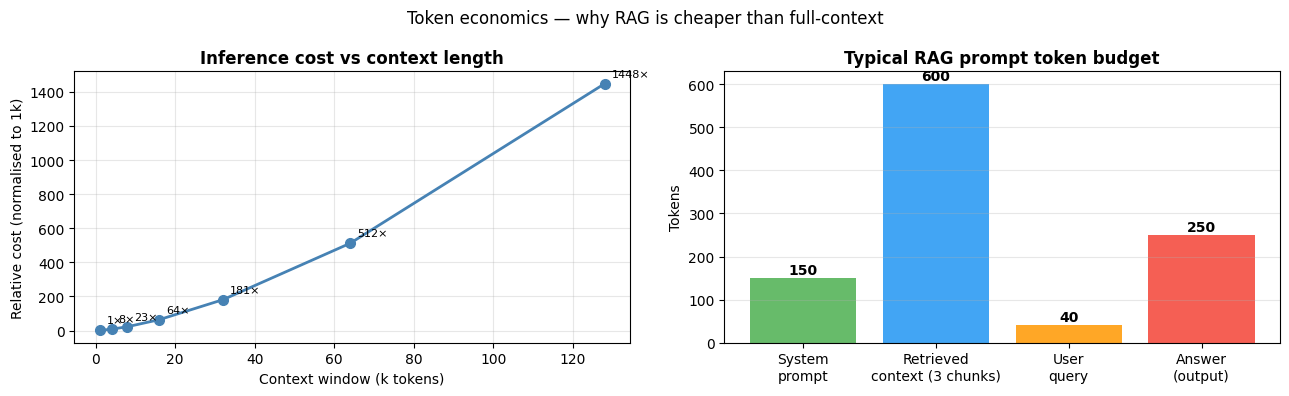

Total RAG prompt: ~1040 tokens  |  Full 7-article KB: ~3500 tokens


In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Illustrate cost vs context window size (attention is O(n^2))
ctx_sizes = np.array([1_000, 4_000, 8_000, 16_000, 32_000, 64_000, 128_000])
relative_cost = (ctx_sizes / ctx_sizes[0]) ** 1.5  # O(n^1.5) practical scaling

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(ctx_sizes / 1000, relative_cost, 'o-', color='steelblue', linewidth=2, markersize=7)
ax1.set_xlabel('Context window (k tokens)')
ax1.set_ylabel('Relative cost (normalised to 1k)')
ax1.set_title('Inference cost vs context length', fontweight='bold')
ax1.grid(alpha=0.3)
for x, y in zip(ctx_sizes / 1000, relative_cost):
    ax1.annotate(f'{y:.0f}×', (x, y), textcoords='offset points', xytext=(5, 5), fontsize=8)

# Token budget breakdown for a RAG prompt
labels   = ['System\nprompt', 'Retrieved\ncontext (3 chunks)', 'User\nquery', 'Answer\n(output)']
sizes    = [150, 600, 40, 250]
colors   = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
ax2.bar(labels, sizes, color=colors, alpha=0.85)
ax2.set_ylabel('Tokens')
ax2.set_title('Typical RAG prompt token budget', fontweight='bold')
ax2.grid(alpha=0.3, axis='y')
for i, (lbl, sz) in enumerate(zip(labels, sizes)):
    ax2.text(i, sz + 10, str(sz), ha='center', fontweight='bold')

plt.suptitle('Token economics — why RAG is cheaper than full-context', fontsize=12)
plt.tight_layout()
plt.savefig('token_economics.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Total RAG prompt: ~{sum(sizes)} tokens  |  Full 7-article KB: ~{7*500} tokens')

## 3. Google Gemini API — First Call

### 3a. Setup

> **Instructor Note:** Each attendee needs a Google Gemini API key. Get a free key at [aistudio.google.com](https://aistudio.google.com/app/apikey). Set it in the cell below. The key is loaded from the environment variable `GEMINI_API_KEY` — never hardcode keys in notebooks.(create.env file (GEMINI_API_KEY=<value>))


 > **If Facing this Issue** An environment file is configured but terminal environment injection is disabled. Enable "python.terminal.useEnvFile" to use environment variables from .env files in terminals.

 **Create .vscode directory:** mkdir -p /Users/name/AI\:ML\ intermediate/.vscode

 **Add**. {
    "python.terminal.useEnvFile": true
}

In [32]:
import os
import google.generativeai as genai

# ── Set your API key here (workshop only — use env vars in production) ──────
# os.environ['GEMINI_API_KEY'] = 'AIza...'   # ← uncomment and paste key

GEMINI_API_KEY = os.environ.get('GEMINI_API_KEY')
if not GEMINI_API_KEY:
    raise EnvironmentError(
        'GEMINI_API_KEY not set.\n'
        'Uncomment the line above and paste your key, or run:\n'
        '  import os; os.environ["GEMINI_API_KEY"] = "AIza..."'
    )

genai.configure(api_key=GEMINI_API_KEY)
MODEL = 'gemini-3.1-flash-lite'   # fast + cheap for workshop demos
print(f'✅ Gemini client ready  |  model: {MODEL}')

✅ Gemini client ready  |  model: gemini-3.1-flash-lite


### 3b. Anatomy of a Gemini API Call

> **Instructor Note:** Walk through every field in the request and response. The `generate_content()` call is the primary interface. `usage_metadata` tracks token counts for cost monitoring — always log these in production. `finish_reason` tells you why generation stopped (STOP = normal, MAX_TOKENS = truncated).

In [33]:
# ── The simplest possible API call ────────────────────────────────────────
model_inst = genai.GenerativeModel(MODEL)
response = model_inst.generate_content(
    "In one sentence, what is Nutanix AOS?",
    generation_config=genai.GenerationConfig(max_output_tokens=256)
)

print('=== Response object anatomy ===')
print(f'model        : {MODEL}')
print(f'finish_reason: {response.candidates[0].finish_reason}   (STOP = finished normally)')
print(f'usage.input  : {response.usage_metadata.prompt_token_count} tokens')
print(f'usage.output : {response.usage_metadata.candidates_token_count} tokens')

# Cost estimate (Flash pricing: $0.075/M input, $0.30/M output)
cost_usd = (response.usage_metadata.prompt_token_count * 0.075 +
            response.usage_metadata.candidates_token_count * 0.30) / 1_000_000
print(f'cost estimate: ${cost_usd:.6f}')
print()
print('=== Answer ===')
print(response.text)

=== Response object anatomy ===
model        : gemini-3.1-flash-lite
finish_reason: 1   (STOP = finished normally)
usage.input  : 12 tokens
usage.output : 56 tokens
cost estimate: $0.000018

=== Answer ===
Nutanix AOS (Acropolis Operating System) is a distributed, software-defined storage platform that serves as the foundation of the Nutanix hyperconverged infrastructure (HCI) stack by virtualizing local storage resources into a unified, scalable pool of data for enterprise applications.


In [34]:
# ── Helper: call Gemini and track cost ────────────────────────────────────
CALL_LOG = []  # accumulates usage across all API calls in this lab

def call_gemini(
    messages,
    system: str = None,
    max_tokens: int = 512,
    temperature: float = 0.3,
    label: str = 'call',
) -> str:
    """Wrapper that calls Gemini and appends usage to CALL_LOG."""
    model_inst = genai.GenerativeModel(
        model_name=MODEL,
        system_instruction=system,
    )
    user_content = messages[-1]['content']
    response = model_inst.generate_content(
        user_content,
        generation_config=genai.GenerationConfig(
            max_output_tokens=max_tokens,
            temperature=temperature,
        )
    )
    in_tok  = response.usage_metadata.prompt_token_count
    out_tok = response.usage_metadata.candidates_token_count
    CALL_LOG.append({
        'label': label,
        'input_tokens': in_tok,
        'output_tokens': out_tok,
        'cost_usd': (in_tok * 0.075 + out_tok * 0.30) / 1_000_000,
    })
    return response.text

# Test
answer = call_gemini(
    messages=[{'role': 'user', 'content': 'What does CVM stand for in Nutanix?'}],
    label='cvm_question'
)
print(answer)

In Nutanix, **CVM** stands for **Controller Virtual Machine**.

Here is a breakdown of what it is and why it is important:

*   **What it is:** The CVM is a specialized virtual machine that runs on every single node in a Nutanix cluster. It acts as the "brain" of the Nutanix storage architecture.
*   **How it works:** It runs the Nutanix software (Acropolis) and is responsible for managing all the local storage resources (SSDs and HDDs) on that specific node. 
*   **The "Storage Controller":** Instead of using a physical hardware RAID controller, Nutanix uses the CVM to present storage to the hypervisor. When a virtual machine needs to read or write data, the request is intercepted by the CVM, which then handles the data placement, replication, compression, and deduplication.
*   **Decoupling:** Because the CVM runs as a VM, it is decoupled from the hypervisor. This allows Nutanix to be hypervisor-agnostic (supporting AHV, ESXi, or Hyper-V) because the storage logic remains consistent 

## 4. API Parameters — Temperature and max_tokens

### 4a. Temperature

Temperature controls **randomness**: 0 = deterministic (always picks the highest-probability token), 1.0 = maximum diversity. For production classification tasks use 0–0.2. For creative or exploratory tasks use 0.5–1.0.

> **Instructor Note:** Run the cell three times with the same inputs to show that temperature=0 produces identical output each time while temperature=1 varies. This matters for repeatability of test suites and audit trails.

In [35]:
PROMPT = 'Describe a Nutanix CVM failure scenario in exactly one sentence.'

print('=== Temperature comparison (same prompt, 3 temperature values) ===\n')
for temp in [0.0, 0.5, 1.0]:
    results = []
    for run in range(2):  # 2 runs to show variance
        text = call_gemini(
            messages=[{'role': 'user', 'content': PROMPT}],
            max_tokens=80,
            temperature=temp,
            label=f'temp_{temp}_run{run}'
        )
        results.append(text.strip())

    same = '✅ identical' if results[0] == results[1] else '⚡ different'
    print(f'temperature={temp}  [{same}]')
    for i, r in enumerate(results):
        print(f'  run {i+1}: {r[:110]}...' if len(r) > 110 else f'  run {i+1}: {r}')
    print()

=== Temperature comparison (same prompt, 3 temperature values) ===

temperature=0.0  [✅ identical]
  run 1: When a Controller VM experiences a hardware or software failure, the local hypervisor automatically redirects ...
  run 2: When a Controller VM experiences a hardware or software failure, the local hypervisor automatically redirects ...

temperature=0.5  [⚡ different]
  run 1: If a Nutanix CVM fails, the local hypervisor automatically redirects I/O requests to a peer CVM within the clu...
  run 2: When a Controller VM experiences a kernel panic or hardware fault, the hypervisor automatically redirects loca...

temperature=1.0  [⚡ different]
  run 1: When a CVM service process crashes or its underlying node experiences a hardware fault, the Nutanix cluster au...
  run 2: If a Nutanix CVM fails, the host’s local storage becomes inaccessible until the CVM reboots or high availabili...



### 4b. max_tokens and Streaming

> **Instructor Note:** `max_tokens` caps the output length. If the model hits the cap before finishing, `stop_reason` will be `max_tokens` — a common debugging clue. Streaming lets you display tokens as they arrive, reducing perceived latency for long outputs.

In [36]:
# max_tokens truncation demo
trunc_model = genai.GenerativeModel(MODEL)
resp_short = trunc_model.generate_content(
    'Explain what Stargate does in Nutanix AOS in detail.',
    generation_config=genai.GenerationConfig(max_output_tokens=20)
)
print(f'finish_reason with max_output_tokens=20 : "{resp_short.candidates[0].finish_reason}"')
print(f'Truncated output                        : {resp_short.text!r}')
print()

# Streaming demo — tokens appear as generated
print('=== Streaming response (tokens arrive in real time) ===')
print('Stargate explanation: ', end='', flush=True)

stream_tokens = 0
stream_model = genai.GenerativeModel(MODEL)
for chunk in stream_model.generate_content(
    'In 2-3 sentences, what is Nutanix Stargate?',
    generation_config=genai.GenerationConfig(max_output_tokens=150),
    stream=True
):
    if chunk.text:
        print(chunk.text, end='', flush=True)
        stream_tokens += 1
print(f'\n\nChunks streamed: {stream_tokens}')

finish_reason with max_output_tokens=20 : "2"
Truncated output                        : 'In the Nutanix architecture, **Stargate** is the core software component'

=== Streaming response (tokens arrive in real time) ===
Stargate explanation: Nutanix Stargate is the core data services process responsible for managing all I/O operations within a Nutanix cluster. It acts as the software-defined storage controller, handling data placement, replication, deduplication, and compression to ensure high performance and reliability across the distributed storage fabric.

Chunks streamed: 3


## 5. Open-Source LLMs via Python

Besides gemini and OpenAI, you can run LLMs locally using **Ollama** (recommended for workshops) or **Hugging Face Transformers**.

> **Instructor Note:** Show the code pattern even if Ollama isn't installed. The interface is nearly identical to the OpenAI client — the only change is the `base_url`. This is important: the same prompt engineering techniques from Lab 5.2 work on any LLM with an OpenAI-compatible endpoint.

In [37]:
import subprocess, sys

# Ensure openai is installed (needed for Ollama's OpenAI-compatible client)
try:
    import openai
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'openai',
                           '--quiet', '--break-system-packages'])
    import openai

# ── Ollama local LLM ──────────────────────────────────────────────────────
OLLAMA_AVAILABLE = False

try:
    import urllib.request
    urllib.request.urlopen('http://localhost:11434', timeout=2)
    OLLAMA_AVAILABLE = True
    print('✅ Ollama is running locally')
except Exception:
    print('ℹ️  Ollama not running — skipping local LLM demo')
    print('   To try: brew install ollama && ollama pull llama3.2 && ollama serve')

if OLLAMA_AVAILABLE:
    from openai import OpenAI as OllamaClient
    ollama = OllamaClient(base_url='http://localhost:11434/v1', api_key='ollama')
    resp = ollama.chat.completions.create(
        model='llama3.2',
        messages=[{'role': 'user', 'content': 'What is Nutanix AOS in one sentence?'}],
        max_tokens=100,
    )
    print(f'Llama3.2 response: {resp.choices[0].message.content}')

# ── Provider comparison table ──────────────────────────────────────────────
print()
providers = pd.DataFrame([
    {'Provider': 'Google Gemini',   'Interface': 'google-generativeai SDK', 'Best model': 'gemini-1.5-pro',   'Cost': '$$',   'Privacy': 'Cloud (Google)'},
    {'Provider': 'Anthropic Claude','Interface': 'anthropic SDK',           'Best model': 'claude-sonnet-4-6','Cost': '$$$',  'Privacy': 'Cloud (US/EU)'},
    {'Provider': 'OpenAI',          'Interface': 'openai SDK',              'Best model': 'gpt-4o',           'Cost': '$$$',  'Privacy': 'Cloud (US)'},
    {'Provider': 'Ollama (local)',  'Interface': 'openai SDK',              'Best model': 'llama3:70b',       'Cost': 'Free', 'Privacy': 'On-prem ✅'},
    {'Provider': 'HuggingFace',     'Interface': 'transformers',            'Best model': 'Mistral-7B',       'Cost': 'Free', 'Privacy': 'On-prem ✅'},
])
print('LLM Provider Comparison:')
print(providers.to_string(index=False))

✅ Ollama is running locally
Llama3.2 response: Nutanix AOS (Acropolis Operating System) is a software-defined storage and compute platform that manages data, applications, and infrastructure as a single unit, allowing for simplified management, scalability, and high-performance computing.

LLM Provider Comparison:
        Provider               Interface        Best model Cost        Privacy
   Google Gemini google-generativeai SDK    gemini-1.5-pro   $$ Cloud (Google)
Anthropic Claude           anthropic SDK claude-sonnet-4-6  $$$  Cloud (US/EU)
          OpenAI              openai SDK            gpt-4o  $$$     Cloud (US)
  Ollama (local)              openai SDK        llama3:70b Free      On-prem ✅
     HuggingFace            transformers        Mistral-7B Free      On-prem ✅


## 6. LLM vs Classical ML — Same Ticket, Different Approaches

We run the Module 4 ticket classifier (TF-IDF + SVM) and Claude side-by-side on the same tickets to compare accuracy, latency, and cost.

> **Instructor Note:** The SVM from Module 4 is faster and cheaper for straightforward tickets that look like training data. Claude excels on ambiguous or compound tickets that span multiple categories — it can explain *why* it chose a category. The practical answer: use the SVM as a first pass (fast lane) and fall back to the LLM for low-confidence tickets.

In [38]:
import time

# Inline test tickets with ground truth
test_cases = [
    ('Stargate crashed after disk sda3 threw IO errors during peak hours', 'storage'),
    ('Prism Central REST API returning 504 timeout for large VM list requests', 'prism'),
    ('Cerebro replication lag exceeded configured RPO of 1 hour between sites', 'replication'),
    ('NIC on node-4 flapping causing packet loss on storage network', 'network'),
    ('AHV live migration stuck due to dirty page transfer timeout after 5 minutes', 'compute'),
    ('Storage write latency spiked to 40ms after enabling erasure coding rebuild', 'performance'),
    ('Cerebro replication is failing AND Prism Central shows stale data because the remote site network link is down', 'replication'),
]

CATEGORIES = ['storage', 'network', 'compute', 'prism', 'replication', 'performance']

CLASSIFY_PROMPT = """You are a Nutanix support triage system. Classify the ticket into exactly one category.
Categories: storage, network, compute, prism, replication, performance
Respond with ONLY the category name, nothing else."""

print(f'{"Ticket":<58} {"Truth":<13} {"Gemini":<13} {"Latency"}')
print('-' * 100)

llm_results = []
for text, truth in test_cases:
    t0 = time.perf_counter()
    pred = call_gemini(
        messages=[{'role': 'user', 'content': f'Ticket: {text}'}],
        system=CLASSIFY_PROMPT,
        max_tokens=20,
        temperature=0.0,
        label='llm_classify'
    ).strip().lower()
    latency_ms = (time.perf_counter() - t0) * 1000

    correct = '✅' if pred == truth else '❌'
    short_text = text[:56] + '..' if len(text) > 56 else text
    print(f'{short_text:<58} {truth:<13} {correct} {pred:<10} {latency_ms:.0f}ms')
    llm_results.append({'text': text, 'truth': truth, 'pred': pred, 'latency_ms': latency_ms})

correct_count = sum(1 for r in llm_results if r['pred'] == r['truth'])
avg_latency   = sum(r['latency_ms'] for r in llm_results) / len(llm_results)
total_cost    = sum(e['cost_usd'] for e in CALL_LOG if e['label'] == 'llm_classify')

print(f'\nLLM accuracy : {correct_count}/{len(test_cases)} = {correct_count/len(test_cases):.0%}')
print(f'Avg latency  : {avg_latency:.0f} ms')
print(f'Total cost   : ${total_cost:.5f}')
print()
print('Compare: Module 4 SVM would be <1ms latency, ~$0 cost, but cannot explain ambiguous cases.')

Ticket                                                     Truth         Gemini        Latency
----------------------------------------------------------------------------------------------------
Stargate crashed after disk sda3 threw IO errors during .. storage       ✅ storage    5446ms
Prism Central REST API returning 504 timeout for large V.. prism         ✅ prism      710ms
Cerebro replication lag exceeded configured RPO of 1 hou.. replication   ✅ replication 1131ms
NIC on node-4 flapping causing packet loss on storage ne.. network       ✅ network    716ms
AHV live migration stuck due to dirty page transfer time.. compute       ✅ compute    4369ms
Storage write latency spiked to 40ms after enabling eras.. performance   ❌ storage    17955ms
Cerebro replication is failing AND Prism Central shows s.. replication   ✅ replication 715ms

LLM accuracy : 6/7 = 86%
Avg latency  : 4434 ms
Total cost   : $0.00003

Compare: Module 4 SVM would be <1ms latency, ~$0 cost, but cannot explain ambig

## 7. Session Cost Summary

In [39]:
import pandas as pd

log_df = pd.DataFrame(CALL_LOG)
print(f'Total API calls    : {len(log_df)}')
print(f'Total input tokens : {log_df["input_tokens"].sum():,}')
print(f'Total output tokens: {log_df["output_tokens"].sum():,}')
print(f'Total cost         : ${log_df["cost_usd"].sum():.5f}')
print()
print('Cost per task:')
print(log_df.groupby('label')[['input_tokens','output_tokens','cost_usd']].sum().to_string())

Total API calls    : 14
Total input tokens : 534
Total output tokens: 516
Total cost         : $0.00019

Cost per task:
               input_tokens  output_tokens  cost_usd
label                                               
cvm_question             12            285  0.000086
llm_classify            432              7  0.000034
temp_0.0_run0            15             35  0.000012
temp_0.0_run1            15             35  0.000012
temp_0.5_run0            15             38  0.000013
temp_0.5_run1            15             37  0.000012
temp_1.0_run0            15             38  0.000013
temp_1.0_run1            15             41  0.000013


## 8. Lab Summary

| Concept | Key Takeaway |
|---------|-------------|
| Classical ML vs LLM | Different tools for different problems — use both |
| Tokens | Billing unit; ~4 chars each; always track `usage_metadata` in production |
| Context window | 1M–2M tokens for Gemini 1.5 — not free, be deliberate |
| Temperature | 0 for deterministic classification; >0.5 for creative tasks |
| Provider choice | Cloud APIs for power, local Ollama for privacy/cost |

> **Instructor Note:** In Lab 5.2 we'll use Gemini to build a systematic prompt engineering toolkit, then in Labs 5.3–5.4 we'll chain it into a RAG pipeline where the classical ML pipeline from Module 4 feeds context to the LLM.

---
## 🎯 Challenges

### Challenge 1
The `call_gemini()` helper tracks cost per call. Modify it to also track wall-clock latency in milliseconds and print a latency percentile table (p50, p90, p99) across all calls made in this lab.

### Challenge 2
Gemini provides `model.count_tokens("text").total_tokens` to get an exact token count before sending a message. Use it to count the exact tokens in five of your test tickets and compare against `estimate_tokens()`. How accurate is the approximation?

### Challenge 3
The LLM classifier returned a category for the compound ambiguous ticket. Now modify the system prompt to ask Gemini to return a **JSON object** with `{"primary_category": ..., "secondary_category": ..., "reasoning": ...}` for that same ticket. Parse the JSON and print the structured result.

In [40]:
# Challenge workspace
